<a href="https://colab.research.google.com/github/Bayronguerrero/Parcial04_Bayron_lopez_2509672020/blob/main/notebook/Correlaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Paso 1: Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Paso 2: Cargar datos
url= "https://raw.githubusercontent.com/Bayronguerrero/Parcial04_Bayron_lopez_2509672020/refs/heads/main/archivo/clave_H_correlacion.csv"
df=pd.read_csv(url)
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,H-C0001,53,867,5,53.63,8.09,2,3,18.49,296.27
1,H-C0002,31,1134,7,68.46,9.43,0,5,29.04,466.41
2,H-C0003,58,1635,5,81.71,5.95,4,3,20.85,399.02
3,H-C0004,38,1185,9,77.26,6.91,3,7,23.43,615.29
4,H-C0005,49,1276,11,88.71,8.34,0,9,8.20,914.97


### Paso 3: Identificar variables numéricas y revisar datos nulos/consistencia

In [3]:
print('Información general del DataFrame:')
df.info()

print('\nEstadísticas descriptivas de las variables numéricas:')
display(df.describe())

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          256 non-null    object 
 1   edad                256 non-null    int64  
 2   ingresos_mensuales  256 non-null    int64  
 3   frecuencia_compra   256 non-null    int64  
 4   ticket_promedio     255 non-null    float64
 5   satisfaccion        255 non-null    float64
 6   reclamos            256 non-null    int64  
 7   uso_app             256 non-null    int64  
 8   tiempo_respuesta    255 non-null    float64
 9   consumo_total       256 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 20.1+ KB

Estadísticas descriptivas de las variables numéricas:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,256.000000,256.000000,256.000000,255.00000,255.000000,256.000000,256.000000,255.000000,256.000000
mean,41.816406,1238.472656,8.070312,72.85400,7.560667,1.550781,5.871094,21.359843,569.450977
std,10.051704,248.618408,3.430391,14.43644,1.262785,1.533086,2.004648,5.630791,225.011440
min,18.000000,619.000000,2.000000,27.97000,2.540000,0.000000,1.000000,7.200000,183.240000
25%,35.000000,1059.250000,6.000000,63.32500,6.845000,1.000000,5.000000,18.205000,444.872500
50%,41.000000,1236.500000,8.000000,72.72000,7.760000,1.000000,6.000000,21.190000,551.300000
75%,48.000000,1407.250000,9.000000,82.97500,8.365000,2.000000,7.000000,25.010000,659.382500
max,68.000000,1899.000000,34.000000,128.77000,9.830000,9.000000,10.000000,40.420000,2389.790000


### Paso 4: Calcular la matriz de correlación

In [4]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.016661,-0.000307,0.150597,0.008511,0.027201,0.116954,-0.063155,0.067152
ingresos_mensuales,0.016661,1.000000,0.051051,0.568912,-0.014222,0.054986,-0.068167,-0.041842,0.292867
frecuencia_compra,-0.000307,0.051051,1.000000,0.038058,0.152668,-0.111787,0.439858,-0.216890,0.879637
ticket_promedio,0.150597,0.568912,0.038058,1.000000,0.056423,-0.039127,-0.026956,-0.038734,0.430907
satisfaccion,0.008511,-0.014222,0.152668,0.056423,1.000000,-0.799622,0.178477,-0.542621,0.262528
reclamos,0.027201,0.054986,-0.111787,-0.039127,-0.799622,1.000000,0.012984,0.473224,-0.211259
uso_app,0.116954,-0.068167,0.439858,-0.026956,0.178477,0.012984,1.000000,-0.324614,0.458099
tiempo_respuesta,-0.063155,-0.041842,-0.216890,-0.038734,-0.542621,0.473224,-0.324614,1.000000,-0.308279
consumo_total,0.067152,0.292867,0.879637,0.430907,0.262528,-0.211259,0.458099,-0.308279,1.000000


### Paso 5: Crear un mapa de calor o gráfico de correlación

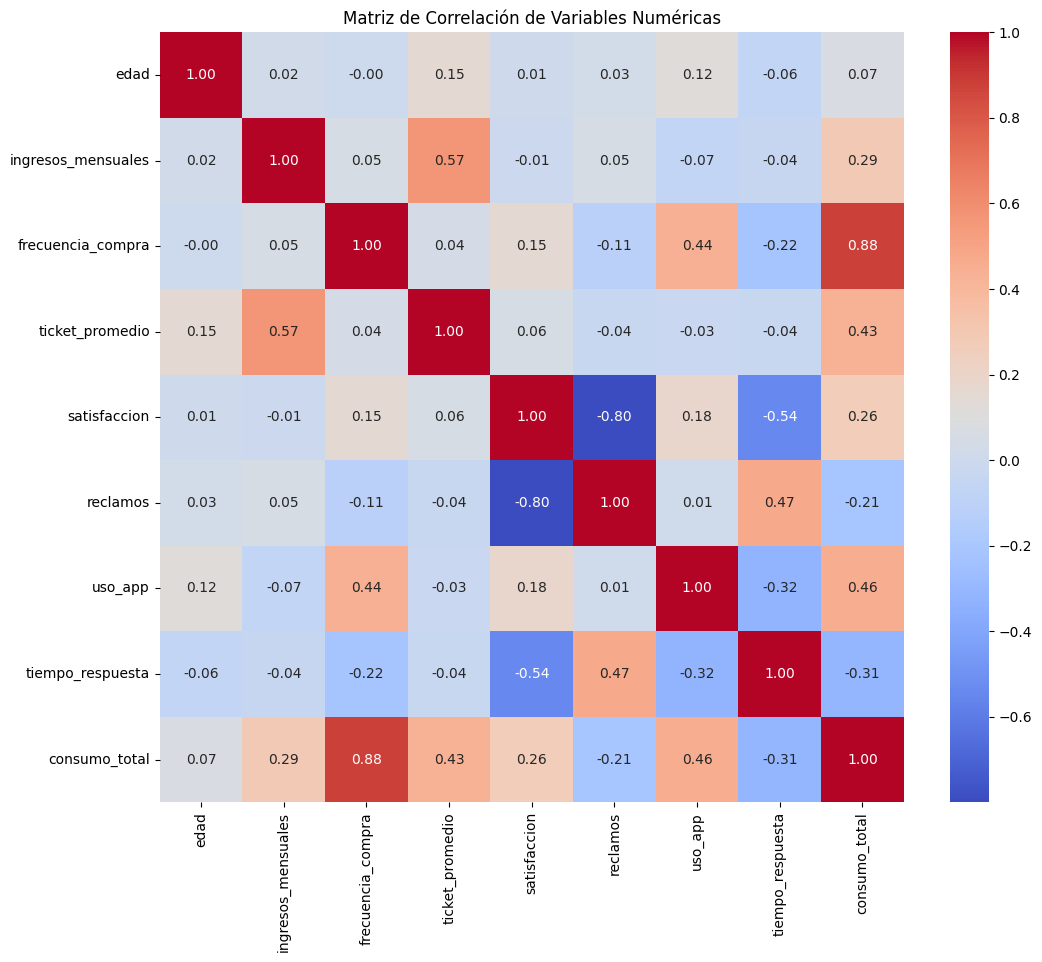

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Paso 6: Identificar las correlaciones más importantes

In [6]:
# Identificar las correlaciones positivas más importantes
print('Correlaciones Positivas Más Importantes:')
positive_correlations = correlation_matrix.unstack().sort_values(ascending=False)
positive_correlations = positive_correlations[positive_correlations.index.get_level_values(0) != positive_correlations.index.get_level_values(1)]
positive_correlations = positive_correlations[positive_correlations > 0.5]
display(positive_correlations.drop_duplicates().head(5))

# Identificar las correlaciones negativas más importantes
print('\nCorrelaciones Negativas Más Importantes:')
negative_correlations = correlation_matrix.unstack().sort_values(ascending=True)
negative_correlations = negative_correlations[negative_correlations.index.get_level_values(0) != negative_correlations.index.get_level_values(1)]
negative_correlations = negative_correlations[negative_correlations < -0.5]
display(negative_correlations.drop_duplicates().head(5))

Correlaciones Positivas Más Importantes:


,,0
frecuencia_compra,consumo_total,0.879637
ticket_promedio,ingresos_mensuales,0.568912



Correlaciones Negativas Más Importantes:


,,0
reclamos,satisfaccion,-0.799622
satisfaccion,tiempo_respuesta,-0.542621


### Paso 7: Conclusión y cómo estas relaciones pueden ayudar a la empresa

El análisis de correlaciones revela patrones clave en el comportamiento de los clientes que pueden ser estratégicamente explotados por la empresa:

*   **Optimización de Ventas:** La alta correlación entre 'frecuencia_compra' y 'consumo_total' sugiere que fomentar la lealtad y las compras repetidas es fundamental. Programas de fidelización, descuentos por volumen o suscripciones podrían ser muy efectivos.
*   **Mejora de la Experiencia del Cliente:** La fuerte correlación negativa entre 'satisfaccion' y 'reclamos', así como entre 'satisfaccion' y 'tiempo_respuesta', indica que invertir en la satisfacción del cliente a través de un servicio rápido y eficiente reducirá significativamente los reclamos. Esto no solo mejora la reputación de la marca, sino que también reduce los costos operativos asociados con la gestión de quejas.
*   **Estrategias de Segmentación y Precios:** La correlación entre 'ingresos_mensuales' y 'ticket_promedio' permite a la empresa diseñar ofertas y estrategias de precios segmentadas. Los clientes con mayores ingresos podrían ser el objetivo de productos de mayor valor, mientras que para otros segmentos se pueden crear ofertas atractivas que impulsen la frecuencia de compra.
*   **Identificación de Riesgos y Oportunidades:** El mapa de calor y las correlaciones permiten a la empresa identificar rápidamente qué variables tienen mayor impacto entre sí, facilitando la toma de decisiones informadas para mitigar riesgos (ej. alta tasa de reclamos) y capitalizar oportunidades de crecimiento (ej. aumentar el consumo total).

En resumen, comprender estas relaciones permite a la empresa tomar decisiones más informadas para mejorar la satisfacción del cliente, optimizar las estrategias de ventas y marketing, y en última instancia, impulsar el crecimiento y la rentabilidad.

### Paso 8: Gráfico de Dispersión entre Satisfacción y Reclamos

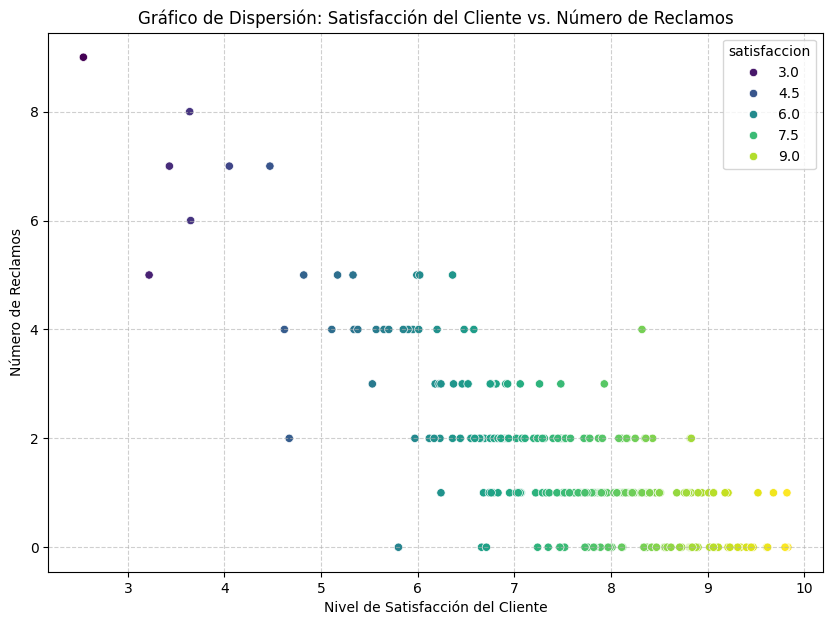

In [7]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='satisfaccion', y='reclamos', data=df, hue='satisfaccion', palette='viridis')
plt.title('Gráfico de Dispersión: Satisfacción del Cliente vs. Número de Reclamos')
plt.xlabel('Nivel de Satisfacción del Cliente')
plt.ylabel('Número de Reclamos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Paso 9: Gráfico de Dispersión entre Frecuencia de Compra y Consumo Total

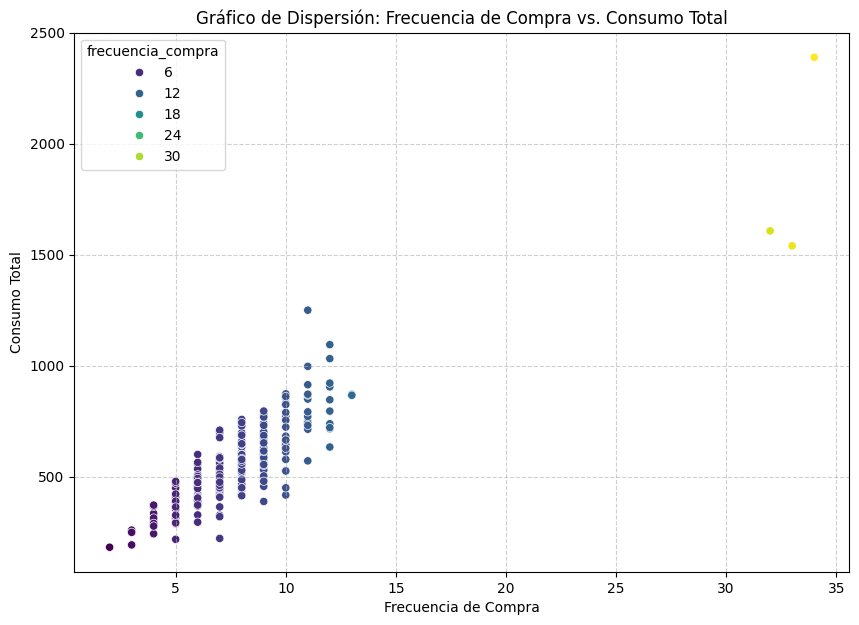

In [8]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='frecuencia_compra', y='consumo_total', data=df, hue='frecuencia_compra', palette='viridis')
plt.title('Gráfico de Dispersión: Frecuencia de Compra vs. Consumo Total')
plt.xlabel('Frecuencia de Compra')
plt.ylabel('Consumo Total')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Paso 10: Gráfico de Dispersión entre Ingresos Mensuales y Ticket Promedio

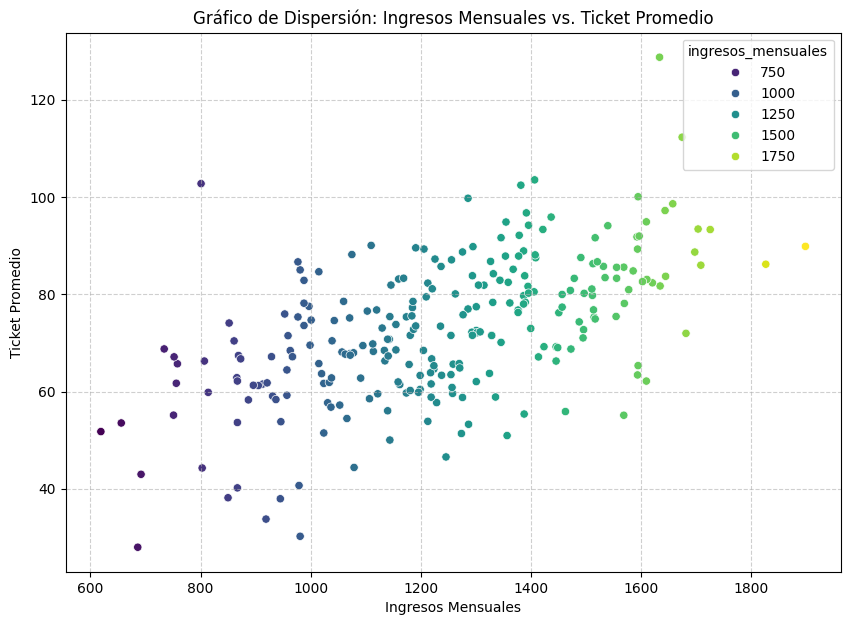

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='ingresos_mensuales', y='ticket_promedio', data=df, hue='ingresos_mensuales', palette='viridis')
plt.title('Gráfico de Dispersión: Ingresos Mensuales vs. Ticket Promedio')
plt.xlabel('Ingresos Mensuales')
plt.ylabel('Ticket Promedio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()